# Trend Prediciton

## 1. Data Validation

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime

In [2]:
TICKERS = "GOOGL"
yearlb = 5
START = (pd.Timestamp.today() - pd.DateOffset(years=yearlb)).strftime("%Y-%m-%d")
END = pd.Timestamp.today().strftime("%Y-%m-%d")

In [3]:
stock = yf.download(tickers=TICKERS, start=START, end=END, progress=False, multi_level_index= False)

/tmp/ipykernel_261550/1212267724.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(tickers=TICKERS, start=START, end=END, progress=False, multi_level_index= False)


In [4]:
stock

,Close,High,Low,Open,Volume
Date,,,,,
2020-10-30,80.251991,83.490163,79.529974,82.800917,99878000
2020-11-02,80.659683,82.344065,80.159130,80.620949,44228000
2020-11-03,81.719368,82.381799,80.053361,80.979476,31432000
2020-11-04,86.694565,87.895283,84.566739,84.694853,71342000
2020-11-05,87.521362,88.977324,86.455214,87.916139,39758000
...,...,...,...,...,...
2025-10-23,253.080002,255.039993,251.850006,252.979996,19901400
2025-10-24,259.920013,261.679993,255.320007,256.579987,28655100
2025-10-27,269.269989,270.140015,264.279999,264.820007,35235200


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
plt.figure(figsize=(14, 7))

<Figure size 1400x700 with 0 Axes>

<Figure size 1400x700 with 0 Axes>

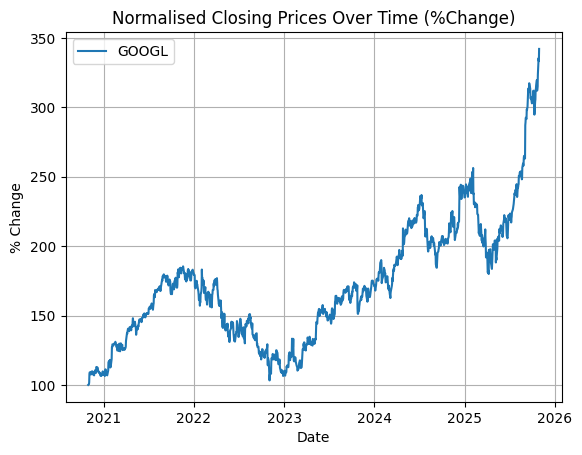

In [7]:
stock_normalized = stock['Close'] / stock['Close'].iloc[0] * 100

plt.plot(stock_normalized, label=TICKERS)

plt.title('Normalised Closing Prices Over Time (%Change)')
plt.xlabel('Date')
plt.ylabel('% Change')
plt.legend()
plt.grid(True)
plt.show()

## 2. Computing Financial Metrics

- **Log Returns (`logret`)**: ค่าลอการิทึมธรรมชาติของการเปลี่ยนแปลงราคาประจำวัน
- **Percentage Returns (`ret`)**: การเปลี่ยนแปลงราคาประจำวันเป็นเปอร์เซ็นต์
- **Realized Volatility (`realized_vol_annual`, `roll30_vol`, `roll60_vol`, `roll180_vol`)**: การวัดความผันผวนของราคาในอดีตในช่วงเวลา rolling window ที่แตกต่างกัน โดยคิดเป็นรายปี
- **Beta (`beta60`)**: การวัดความผันผวนของหุ้นเทียบกับ benchmark ในช่วง rolling window 60 วัน
- **Skewness (`skew60`)**: การวัดความไม่สมมาตรของการกระจายผลตอบแทนในช่วง rolling window 60 วัน
- **Kurtosis (`kurt60`)**: การวัด "tailedness" ของการกระจายผลตอบแทนเทียบกับการกระจายปกติในช่วง rolling window 60 วัน
- **Average True Range (`ATR7`)**: การวัดความผันผวนของตลาด คำนวณในช่วง rolling window 7 วัน
- **Big Move (`big_move`)**: ตัวบ่งชี้ไบนารี (0 หรือ 1) หากผลตอบแทนรายวันแบบสัมบูรณ์มากกว่า 2%
- **Monthly and Quarterly Returns (`ret_1m`, `ret_3m`)**: การเปลี่ยนแปลงราคาเป็นเปอร์เซ็นต์ในช่วงประมาณ 1 เดือน (21 วันทำการ) และ 3 เดือน (63 วันทำการ)

In [8]:
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestRegressor
import json

In [9]:
# ---------- Compute factor metrics ----------
def compute_factors(df):
    df = df.copy()
    df['logret'] = np.log(df['Close']).diff()
    df['ret'] = df['Close'].pct_change()
    df['realized_vol_annual'] = df['logret'].rolling(window=252).std() * np.sqrt(252)
    df['roll30_vol'] = df['logret'].rolling(30).std() * np.sqrt(252)
    df['roll60_vol'] = df['logret'].rolling(60).std() * np.sqrt(252)
    df['roll180_vol'] = df['logret'].rolling(180).std() * np.sqrt(252)
    # beta: need benchmark logret
    df['skew60'] = df['logret'].rolling(60).apply(lambda x: skew(x.dropna()), raw=False)
    df['kurt60'] = df['logret'].rolling(60).apply(lambda x: kurtosis(x.dropna(), fisher=False), raw=False)

    # ATR
    hl = df['High'] - df['Low']
    hc = (df['High'] - df['Close'].shift()).abs()
    lc = (df['Low'] - df['Close'].shift()).abs()
    tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    df['ATR5'] = tr.rolling(5).mean()
    df['ROC5'] = df['Close'].pct_change(periods=5) * 100
    df['ROC10'] = df['Close'].pct_change(periods=10) * 100

    # % of days with > 2% move (abs daily return)
    df['big_move'] = (df['ret'].abs() > 0.02).astype(int)
    df['spread'] = df['High'] - df['Low']
    
    return df

In [10]:
df = compute_factors(stock)

In [11]:
df.tail()

,Close,High,Low,Open,Volume,logret,ret,realized_vol_annual,roll30_vol,roll60_vol,roll180_vol,skew60,kurt60,ATR5,ROC5,ROC10,big_move,spread
Date,,,,,,,,,,,,,,,,,,
2025-10-23,253.080002,255.039993,251.850006,252.979996,19901400,0.005507,0.005523,0.322717,0.237778,0.280601,0.317682,1.897595,9.745286,6.651993,0.644236,4.782016,0,3.189987
2025-10-24,259.920013,261.679993,255.320007,256.579987,28655100,0.026668,0.027027,0.323645,0.248533,0.278102,0.319067,1.909967,9.648890,7.089990,2.613506,9.870231,1,6.359985
2025-10-27,269.269989,270.140015,264.279999,264.820007,35235200,0.035341,0.035973,0.324962,0.237113,0.281840,0.318812,1.800932,8.913416,8.327994,4.958099,10.288755,1,5.860016
2025-10-28,267.470001,270.730011,266.500000,269.690002,29738600,-0.006707,-0.006685,0.325071,0.238269,0.278158,0.318946,1.926068,9.598743,6.693997,6.791501,8.971279,0,4.230011
2025-10-29,274.570007,275.335999,267.670013,267.755005,38492113,0.026199,0.026545,0.325691,0.246710,0.281008,0.320073,1.817375,9.050286,6.853198,9.090550,9.377369,1,7.665985


## 3. Machine Learning Trend Prediction

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas_ta as ta

In [13]:
feature_columns0 = ['Open', 'High', 'Low', 'Close', 'Volume', 'logret', 'big_move', 'spread']

istock = df[feature_columns0]

# feature engineering with indicators from technical analysis
istock['RSI14'] = ta.rsi(istock['Close'], length=14)
istock['EMA5'] = ta.wma(istock['Close'], length=5)
istock['EMA10'] = ta.wma(istock['Close'], length=10)
istock['ATR'] = ta.atr(high=istock['High'], low=istock['Low'], close=istock['Close'], mamode="rma")

istock['MA_diff'] = istock['EMA5'] - istock['EMA10']
istock['price_diff'] = istock['Close'] - istock['EMA5']

imacd = ta.macd(istock['Close'], fast=12, slow=26, signal=9)
istock['macd'] = imacd['MACD_12_26_9']
istock['macd_signal'] = imacd['MACDs_12_26_9']
istock['macd_hist'] = imacd['MACDh_12_26_9']

istock['MOM5'] = ta.mom(istock['Close'], length=5)
istock['mom_type'] = np.where((istock.MOM5 >= 0), 1, -1)
istock['strong_pos'] = np.where((istock.MOM5 >= 0) & (istock.MOM5 > istock.MOM5.shift(1)), 1, 0)
istock['strong_neg'] = np.where((istock.MOM5 < 0) & (istock.MOM5 < istock.MOM5.shift(1)), 1, 0)

istock.tail()

,Open,High,Low,Close,Volume,logret,big_move,spread,RSI14,EMA5,...,ATR,MA_diff,price_diff,macd,macd_signal,macd_hist,MOM5,mom_type,strong_pos,strong_neg
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-23,252.979996,255.039993,251.850006,253.080002,19901400,0.005507,0,3.189987,60.849995,252.662668,...,6.125328,1.063031,0.417334,4.442531,4.695822,-0.253291,1.619995,1,1,0
2025-10-24,256.579987,261.679993,255.320007,259.920013,28655100,0.026668,1,6.359985,66.986005,254.964006,...,6.302089,1.446912,4.956008,4.910172,4.738692,0.171481,6.620010,1,1,0
2025-10-27,264.820007,270.140015,264.279999,269.269989,35235200,0.035341,1,5.860016,73.175141,259.940668,...,6.581940,3.230667,9.329321,5.966469,4.984247,0.982222,12.720001,1,1,0
2025-10-28,269.690002,270.730011,266.500000,267.470001,29738600,-0.006707,0,4.230011,70.437481,263.469334,...,6.413945,4.350424,4.000667,6.582469,5.303892,1.278577,17.009995,1,1,0
2025-10-29,267.755005,275.335999,267.670013,274.570007,38492113,0.026199,1,7.665985,74.491411,268.230669,...,6.517663,5.812303,6.339338,7.556459,5.754405,1.802054,22.880005,1,1,0


In [14]:
# create label for the current price if it is going up or not
istock['future'] = (istock['Close'].shift(-1) > istock['Close']).astype(int)

In [16]:
# feature selection (X)
feature_columns = [
    'logret', 'mom_type', 'strong_pos', 'strong_neg', 'price_diff', 'Close', 'MOM5', 'macd_signal', 'RSI14', 'ATR'
]
X0 = istock[feature_columns]

# labels (y)
y0 = istock['future']

# drop rows with nan and align X and y
combined_df = pd.concat([X0, y0], axis=1).dropna()
X = combined_df[feature_columns]
y = combined_df['future']

combined_df.tail(10)

,logret,mom_type,strong_pos,strong_neg,price_diff,Close,MOM5,macd_signal,RSI14,ATR,future
Date,,,,,,,,,,,
2025-10-16,0.001712,1,1,0,3.284006,251.460007,9.930008,5.034758,63.180182,5.913622,1
2025-10-17,0.007291,1,1,0,2.601335,253.300003,16.729996,4.906362,64.902340,5.949078,1
2025-10-20,0.012749,1,0,0,3.360657,256.549988,12.399994,4.887339,67.769836,5.812000,0
2025-10-21,-0.024024,1,0,0,-2.363327,250.460007,5.010010,4.829563,58.177980,6.282571,1
2025-10-22,0.004899,1,0,0,-0.843332,251.690002,0.660004,4.759144,59.427018,6.338815,1
2025-10-23,0.005507,1,1,0,0.417334,253.080002,1.619995,4.695822,60.849995,6.125328,1
2025-10-24,0.026668,1,1,0,4.956008,259.920013,6.620010,4.738692,66.986005,6.302089,1
2025-10-27,0.035341,1,1,0,9.329321,269.269989,12.720001,4.984247,73.175141,6.581940,0
2025-10-28,-0.006707,1,1,0,4.000667,267.470001,17.009995,5.303892,70.437481,6.413945,1


Trend Prediction

In [17]:
# prepare train and test size
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (977, 10)
X_test Shape: (245, 10)
y_train Shape: (977,)
y_test Shape: (245,)


In [21]:
# SVC model training
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

cls = svm_model.fit(X_train, y_train)
train_confusion = confusion_matrix(y_train, cls.predict(X_train))
test_confustoin = confusion_matrix(y_test, cls.predict(X_test))

train_report = classification_report(y_train, cls.predict(X_train))
test_report = classification_report(y_test, cls.predict(X_test))

print(f"Train Dataset Confusion Matrix:\n{train_confusion}")
print(f"Train Dataset Report:\n{train_report}")
print("----------------------------------")
print(f"Test Dataset Confusion Matrix:\n{test_confustoin}")
print(f"Test Dataset Report:\n{test_report}")

Train Dataset Confusion Matrix:
[[  0 449]
 [  0 528]]
Train Dataset Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       449
           1       0.54      1.00      0.70       528

    accuracy                           0.54       977
   macro avg       0.27      0.50      0.35       977
weighted avg       0.29      0.54      0.38       977

----------------------------------
Test Dataset Confusion Matrix:
[[  0 114]
 [  0 131]]
Test Dataset Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       114
           1       0.53      1.00      0.70       131

    accuracy                           0.53       245
   macro avg       0.27      0.50      0.35       245
weighted avg       0.29      0.53      0.37       245



/home/akito1961/Documents/Quant Python/trend_prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/akito1961/Documents/Quant Python/trend_prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/akito1961/Documents/Quant Python/trend_prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 